# 06 — Fairness audit

This is the point of the project: take the same model and look at how its errors are distributed across patient subgroups. Average AUC tells me almost nothing about whether the model would be safe to deploy — what matters is whether one group systematically gets worse predictions than another.

## What I'm computing

For each demographic grouping (sex, age band, insurance, race), I report per-subgroup:

- **Sample size** (small N is the elephant in the room; everything else depends on it).
- **Outcome prevalence** — the actual mortality rate in that subgroup.
- **Predicted positive rate** — how often the model flags that subgroup.
- **AUC-ROC** when both outcome classes are present.
- **True positive rate (sensitivity)** — of the patients who died, what fraction did the model catch.
- **False positive rate** — of the survivors, what fraction were wrongly flagged.
- **False negative rate** — *of the deaths, what fraction was missed*. This is the one I care about most for a mortality model.

And then I use `fairlearn` to compute the standard disparity differences (demographic parity, equalized odds, equal opportunity).

## What this audit does NOT do

- It does not establish *why* any gap exists (data composition, labeling, measurement, model architecture — each is a different mechanism).
- It does not produce reliable estimates at this sample size. The numbers are illustrative; the *workflow* is the deliverable.
- It does not interrogate the categories themselves. Race in MIMIC is a self-reported, aggregated label — auditing along it is necessary, but treating gaps as biological is a category error. Celi and others have written extensively about this.

## Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score

DATA_DIR = Path("../data")
DERIVED = DATA_DIR / "derived"

sns.set_theme(style="whitegrid", context="notebook")

## Load predictions

In [2]:
predictions = pd.read_csv(DERIVED / "predictions.csv")
print(f"predictions: {predictions.shape}")
print(f"overall mortality rate: {predictions['hospital_expire_flag'].mean():.1%}")
predictions.head()

predictions: (85, 9)
overall mortality rate: 8.2%


,stay_id,subject_id,anchor_age,gender,race,insurance,hospital_expire_flag,pred_proba,pred_label
0,37067082,10001217,55,F,WHITE,Other,0,0.005545,0
1,31205490,10001725,46,F,WHITE,Other,0,0.065213,0
2,33987268,10002428,80,F,WHITE,Medicare,0,0.185942,0
3,36753294,10002495,81,M,UNKNOWN,Medicare,0,0.862115,1
4,37049133,10002930,48,F,BLACK/AFRICAN AMERICAN,Medicare,0,0.000933,0


## Helper: per-subgroup metrics

A single function that produces a comparable row for each subgroup of a given grouping variable.

In [3]:
def subgroup_metrics(df, group_col):
    rows = []
    for grp, sub in df.groupby(group_col, dropna=False):
        n = len(sub)
        y_true = sub["hospital_expire_flag"].values
        y_proba = sub["pred_proba"].values
        y_pred = sub["pred_label"].values

        prevalence = y_true.mean() if n > 0 else np.nan
        pred_pos_rate = y_pred.mean() if n > 0 else np.nan

        # AUC needs both outcome classes in the subgroup
        auc = roc_auc_score(y_true, y_proba) if len(np.unique(y_true)) == 2 else np.nan

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel() if cm.shape == (2, 2) else (0, 0, 0, 0)

        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan

        rows.append({
            "group": grp,
            "n": n,
            "prevalence": prevalence,
            "pred_pos_rate": pred_pos_rate,
            "auc": auc,
            "tpr": tpr,
            "fpr": fpr,
            "fnr": fnr,
            "ppv": ppv,
        })
    return pd.DataFrame(rows).set_index("group")


def plot_subgroup_metrics(metrics_df, title, metrics=("prevalence", "pred_pos_rate", "tpr", "fpr")):
    plot_df = metrics_df[list(metrics)].reset_index().melt(
        id_vars="group", var_name="metric", value_name="value"
    )
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(data=plot_df, x="group", y="value", hue="metric", ax=ax)
    ax.set_title(title)
    ax.set_ylabel("Rate")
    ax.set_ylim(0, 1)
    ax.legend(loc="upper right", fontsize=9)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

## Stratify by sex

In [4]:
sex_metrics = subgroup_metrics(predictions, "gender")
sex_metrics

,n,prevalence,pred_pos_rate,auc,tpr,fpr,fnr,ppv
group,,,,,,,,
F,39,0.051282,0.000000,0.459459,0.0,0.000000,1.0,NaN
M,46,0.108696,0.086957,0.200000,0.2,0.073171,0.8,0.25


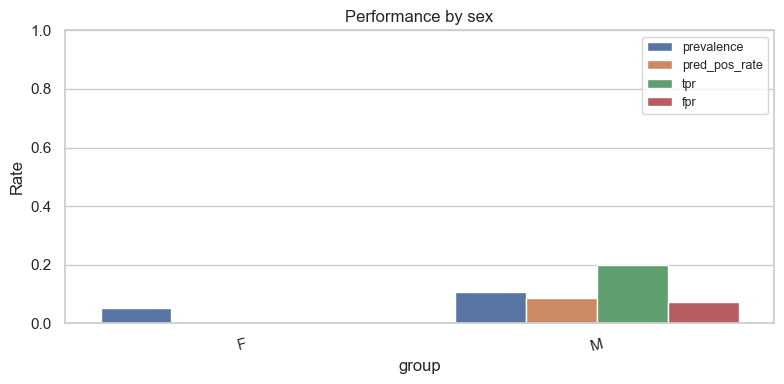

In [5]:
plot_subgroup_metrics(sex_metrics, "Performance by sex")

## Stratify by age band

In [6]:
age_bins = [0, 40, 60, 75, 120]
age_labels = ["<40", "40-59", "60-74", "75+"]
predictions["age_band"] = pd.cut(
    predictions["anchor_age"], bins=age_bins, labels=age_labels, right=False
)

age_metrics = subgroup_metrics(predictions, "age_band")
age_metrics

,n,prevalence,pred_pos_rate,auc,tpr,fpr,fnr,ppv
group,,,,,,,,
<40,9,0.000000,0.000000,NaN,NaN,0.000000,NaN,NaN
40-59,28,0.000000,0.035714,NaN,NaN,0.035714,NaN,0.0
60-74,28,0.178571,0.035714,0.356522,0.2,0.000000,0.8,1.0
75+,20,0.100000,0.100000,0.027778,0.0,0.111111,1.0,0.0


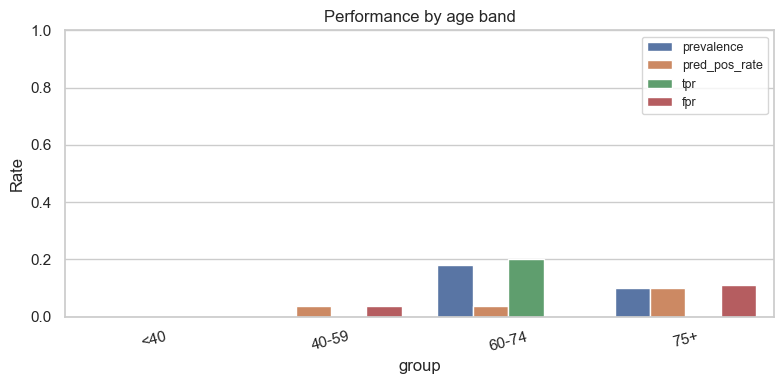

In [7]:
plot_subgroup_metrics(age_metrics, "Performance by age band")

## Stratify by insurance

In [8]:
insurance_metrics = subgroup_metrics(predictions, "insurance")
insurance_metrics

,n,prevalence,pred_pos_rate,auc,tpr,fpr,fnr,ppv
group,,,,,,,,
Medicaid,6,0.000000,0.166667,NaN,NaN,0.166667,NaN,0.000000
Medicare,31,0.161290,0.096774,0.253846,0.2,0.076923,0.8,0.333333
Other,48,0.041667,0.000000,0.423913,0.0,0.000000,1.0,NaN


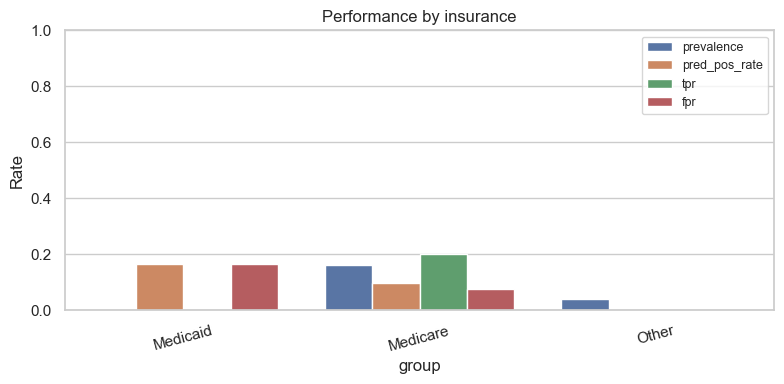

In [9]:
plot_subgroup_metrics(insurance_metrics, "Performance by insurance")

## Stratify by race

The raw `race` field in MIMIC has many sub-categories with overlap and small N. I collapse them into broader groups for readability — the full categories are still preserved in the dataset for any future re-analysis.

In [10]:
def collapse_race(value):
    if pd.isna(value):
        return "UNKNOWN"
    v = str(value).upper()
    if "WHITE" in v:
        return "WHITE"
    if "BLACK" in v or "AFRICAN" in v:
        return "BLACK/AFRICAN AMERICAN"
    if "HISPANIC" in v or "LATINO" in v:
        return "HISPANIC/LATINO"
    if "ASIAN" in v:
        return "ASIAN"
    if "UNKNOWN" in v or "DECLINE" in v or "UNABLE" in v:
        return "UNKNOWN"
    return "OTHER"

predictions["race_collapsed"] = predictions["race"].apply(collapse_race)
predictions["race_collapsed"].value_counts(dropna=False)

race_collapsed
WHITE                     54
UNKNOWN                   13
BLACK/AFRICAN AMERICAN    10
OTHER                      5
HISPANIC/LATINO            3
Name: count, dtype: int64

In [11]:
race_metrics = subgroup_metrics(predictions, "race_collapsed")
race_metrics

,n,prevalence,pred_pos_rate,auc,tpr,fpr,fnr,ppv
group,,,,,,,,
BLACK/AFRICAN AMERICAN,10,0.000000,0.100000,NaN,NaN,0.10,NaN,0.0
HISPANIC/LATINO,3,0.000000,0.000000,NaN,NaN,0.00,NaN,NaN
OTHER,5,0.000000,0.000000,NaN,NaN,0.00,NaN,NaN
UNKNOWN,13,0.230769,0.076923,0.20,0.00,0.10,1.00,0.0
WHITE,54,0.074074,0.037037,0.36,0.25,0.02,0.75,0.5


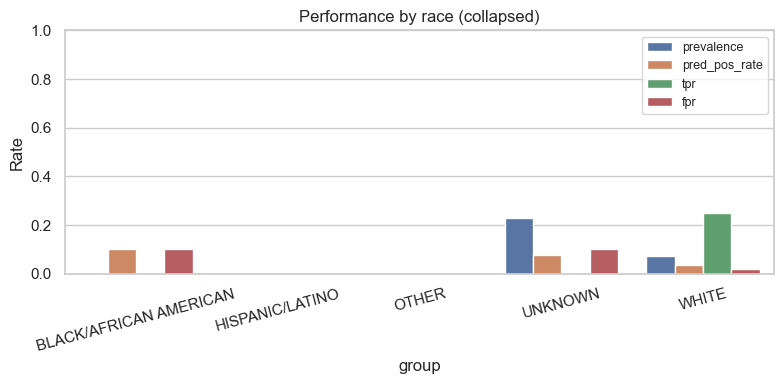

In [12]:
plot_subgroup_metrics(race_metrics, "Performance by race (collapsed)")

## Standardized fairness metrics with `fairlearn`

`MetricFrame` gives a clean stratified view, and the disparity functions (`*_difference`) return the worst-case gap across groups for each metric. These are the quantities you'd typically report in a fairness audit.

In [13]:
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    true_positive_rate,
    false_positive_rate,
    demographic_parity_difference,
    equalized_odds_difference,
)

fairness_metrics = {
    "accuracy": accuracy_score,
    "selection_rate": selection_rate,
    "tpr": true_positive_rate,
    "fpr": false_positive_rate,
}

def fairness_summary(sensitive_col):
    mf = MetricFrame(
        metrics=fairness_metrics,
        y_true=predictions["hospital_expire_flag"],
        y_pred=predictions["pred_label"],
        sensitive_features=predictions[sensitive_col],
    )
    print(f"=== Stratified by {sensitive_col} ===")
    print(mf.by_group)
    print()
    print(f"  demographic parity diff: {demographic_parity_difference(predictions['hospital_expire_flag'], predictions['pred_label'], sensitive_features=predictions[sensitive_col]):.3f}")
    print(f"  equalized odds diff:     {equalized_odds_difference(predictions['hospital_expire_flag'], predictions['pred_label'], sensitive_features=predictions[sensitive_col]):.3f}")
    print()

fairness_summary("gender")

=== Stratified by gender ===
        accuracy  selection_rate  tpr       fpr
gender                                         
F       0.948718        0.000000  0.0  0.000000
M       0.847826        0.086957  0.2  0.073171

  demographic parity diff: 0.087
  equalized odds diff:     0.200



In [14]:
fairness_summary("age_band")

=== Stratified by age_band ===
          accuracy  selection_rate  tpr       fpr
age_band                                         
40-59     0.964286        0.035714  0.0  0.035714
60-74     0.857143        0.035714  0.2  0.000000
75+       0.800000        0.100000  0.0  0.111111
<40       1.000000        0.000000  0.0  0.000000

  demographic parity diff: 0.100
  equalized odds diff:     0.200



In [15]:
fairness_summary("insurance")

=== Stratified by insurance ===
           accuracy  selection_rate  tpr       fpr
insurance                                         
Medicaid   0.833333        0.166667  0.0  0.166667
Medicare   0.806452        0.096774  0.2  0.076923
Other      0.958333        0.000000  0.0  0.000000

  demographic parity diff: 0.167
  equalized odds diff:     0.200



In [16]:
fairness_summary("race_collapsed")

=== Stratified by race_collapsed ===
                        accuracy  selection_rate   tpr   fpr
race_collapsed                                              
BLACK/AFRICAN AMERICAN  0.900000        0.100000  0.00  0.10
HISPANIC/LATINO         1.000000        0.000000  0.00  0.00
OTHER                   1.000000        0.000000  0.00  0.00
UNKNOWN                 0.692308        0.076923  0.00  0.10
WHITE                   0.925926        0.037037  0.25  0.02

  demographic parity diff: 0.100
  equalized odds diff:     0.250



## Takeaways

At this sample size (~50 stays, with subgroups of 5-25 each), specific numbers are not estimates of population-level disparities — they're a methodology demonstration. The pipeline is honest about that.

A few things worth pulling out, even with the caveat:

- **The disparity differences are mechanical**: they don't tell you which subgroup is being harmed, only that the model behaves unequally. Reading the per-subgroup TPR / FPR table is more informative than the single-number gap.
- **False-negative rate is the metric to anchor on for a mortality model**: a missed death is the worst error. Any subgroup with elevated FNR deserves close attention before deployment.
- **An audit alone doesn't fix bias.** Even if the model has equal error rates across groups, the data themselves can be biased (who got admitted, who got measurements, who got the diagnostic codes attached). A fair-by-the-numbers model on biased data is still a bias problem.

## Next steps

- Scale to full MIMIC-IV (PhysioNet credentialing in progress). With ~300k stays the audit becomes statistically meaningful.
- Add more features and better imputation (last-value-carried-forward, missingness indicators).
- Compare model architectures with the same audit (XGBoost, simple neural nets).
- Bring intersectional subgroups in (e.g., race × insurance) once N permits.
- The bigger open question — beyond model audit — is what to *do* about a disparity once found. That's where the fairness literature gets interesting, and where I'd want to learn from a research group working on this seriously.